# Lab Instructions

You have been hired by a record executive to design a guaranteed smash hit song based on data.  The exec has decided that if you make a song that has all the most popular features of recent songs then it will definitely be a hit.  So if - for example - the most common key in the Spotify data is C# then we would want the song we are designing to also be in C#.  If a "typical" value of BPM is between 120 and 130 then we would want the song we are designing to also have a tempo between 120 and 130 BMP.

Visualize and describe the distribution of:
* BPM
* Key
* Mode
* Danceability
* Energy
* Speechiness
* Acousticness

Based on your visualizations and calculations, what values for each of these features would make a song a guaranteed smash hit?  For quantitative features, you should propose a range of values.

Use a large language model to help you write code to identify if there are any songs in the Spotify dataset that meet all of the criteria we determined.  What is/are the artist(s) and title(s) of the song?  Were any of these songs actually popular?

Pick a song that you know was a smash hit. How do the values of BPM, key, mode, danceability, etc. compare to other songs? 

**Hint:**  Import the Spotify data using `df = pd.read_csv('spotify-2023.csv', encoding='ISO-8859-1')`.

## Solution

This notebook visualizes the required Spotify features, defines an engineered smash hit using the most common categorical values and the interquartile range for quantitative values, identifies matching songs, and compares a known smash hit to the engineered profile.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from math import floor, ceil

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 140)

df = pd.read_csv('../../Lab/spotify-2023.csv', encoding='ISO-8859-1')

relevant_cols = [
    'track_name', 'artist(s)_name', 'streams', 'bpm', 'key', 'mode',
    'danceability_%', 'energy_%', 'speechiness_%', 'acousticness_%'
]

display(df[relevant_cols].head())
print(f"Rows: {len(df)}")
print(f"Columns: {len(df.columns)}")

,track_name,artist(s)_name,streams,bpm,key,mode,danceability_%,energy_%,speechiness_%,acousticness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",141381703,125,B,Major,80,83,4,31
1,LALA,Myke Towers,133716286,92,C#,Major,71,74,4,7
2,vampire,Olivia Rodrigo,140003974,138,F,Major,51,53,6,17
3,Cruel Summer,Taylor Swift,800840817,170,A,Major,55,72,15,11
4,WHERE SHE GOES,Bad Bunny,303236322,144,A,Minor,65,80,6,14


Rows: 953
Columns: 24


In [3]:
def clean_count_table(series, feature_name):
    return (
        series.value_counts(dropna=False)
        .rename_axis(feature_name)
        .reset_index(name='count')
    )

def show_numeric_feature(df, col, title, xlabel, bins=20):
    plt.figure(figsize=(8,5))
    plt.hist(df[col].dropna(), bins=bins, edgecolor='black')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('Frequency')
    plt.show()

    summary = pd.DataFrame({
        'feature': [col],
        'mean': [round(df[col].mean(), 2)],
        'median': [round(df[col].median(), 2)],
        'Q1': [round(df[col].quantile(0.25), 2)],
        'Q3': [round(df[col].quantile(0.75), 2)],
        'min': [round(df[col].min(), 2)],
        'max': [round(df[col].max(), 2)]
    })

    display(summary)

def show_categorical_feature(df, col, title, xlabel, top_n=None):
    counts = df[col].value_counts(dropna=False)
    plot_counts = counts.head(top_n) if top_n is not None else counts

    plt.figure(figsize=(12,5) if top_n else (8,5))
    plot_counts.plot(kind='bar', edgecolor='black')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('Count')
    plt.xticks(rotation=45 if top_n else 0, ha='right' if top_n else 'center')
    plt.tight_layout()
    plt.show()

    table = clean_count_table(df[col], col)
    if top_n is not None:
        table = table.head(top_n)

    display(table)

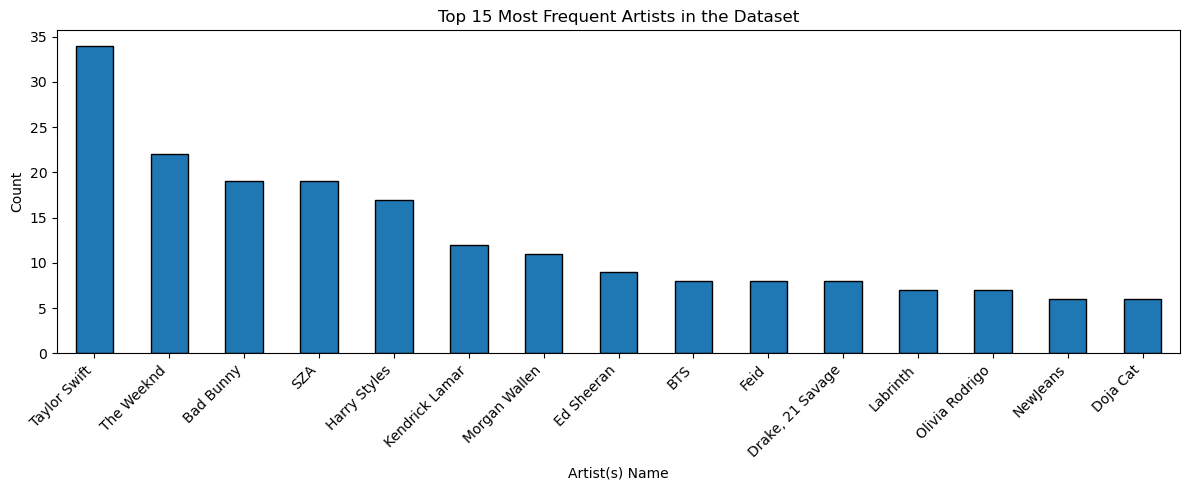

,artist(s)_name,count
0,Taylor Swift,34
1,The Weeknd,22
2,Bad Bunny,19
3,SZA,19
4,Harry Styles,17
5,Kendrick Lamar,12
6,Morgan Wallen,11
7,Ed Sheeran,9
8,BTS,8
9,Feid,8


In [4]:
show_categorical_feature(
    df,
    'artist(s)_name',
    'Top 15 Most Frequent Artists in the Dataset',
    'Artist(s) Name',
    top_n=15
)

The artist visualization shows which artists appear most often in the dataset. 
This helps identify which artists are most strongly represented among recent popular songs. 
Although an artist name is not a musical feature that can be engineered like BPM or key, it still provides useful context about who dominates the dataset.

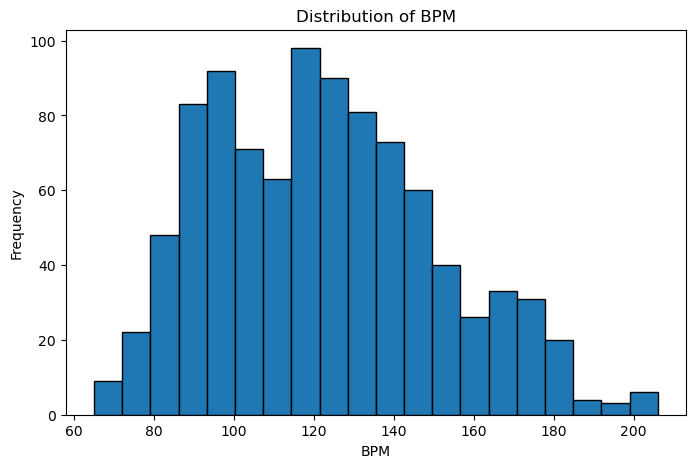

,feature,mean,median,Q1,Q3,min,max
0,bpm,122.54,121.0,100.0,140.0,65,206


In [5]:
show_numeric_feature(df, 'bpm', 'Distribution of BPM', 'BPM')

The BPM distribution shows the most common tempo range in the dataset. 
Most songs cluster in a moderate-to-upbeat tempo range, rather than at very slow or very fast tempos. 
I will use the middle 50% of BPM values, from Q1 to Q3, as the target range for an engineered smash hit.

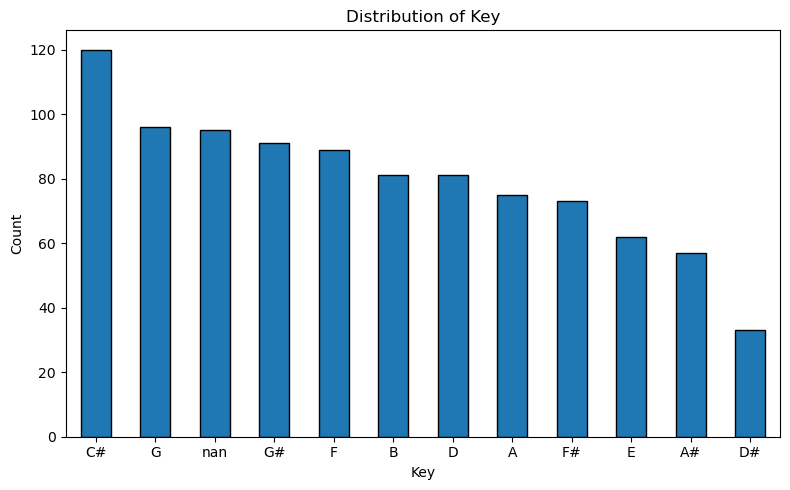

,key,count
0,C#,120
1,G,96
2,NaN,95
3,G#,91
4,F,89
5,B,81
6,D,81
7,A,75
8,F#,73
9,E,62


In [6]:
show_categorical_feature(df, 'key', 'Distribution of Key', 'Key')

The bar chart for key shows which musical key appears most often in the dataset. 
I selected the most common key as the best choice for the engineered smash hit.

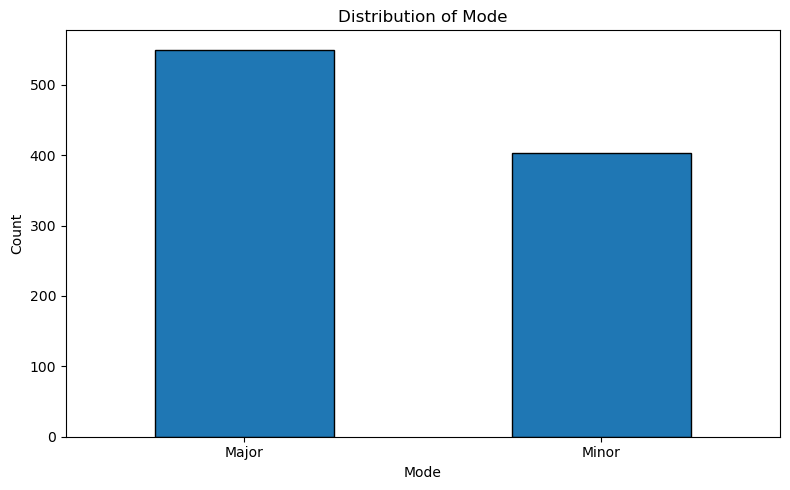

,mode,count
0,Major,550
1,Minor,403


In [7]:
show_categorical_feature(df, 'mode', 'Distribution of Mode', 'Mode')

The mode chart shows whether Major or Minor is more common among the songs in the dataset. 
I selected the most common mode as part of the engineered smash hit profile.

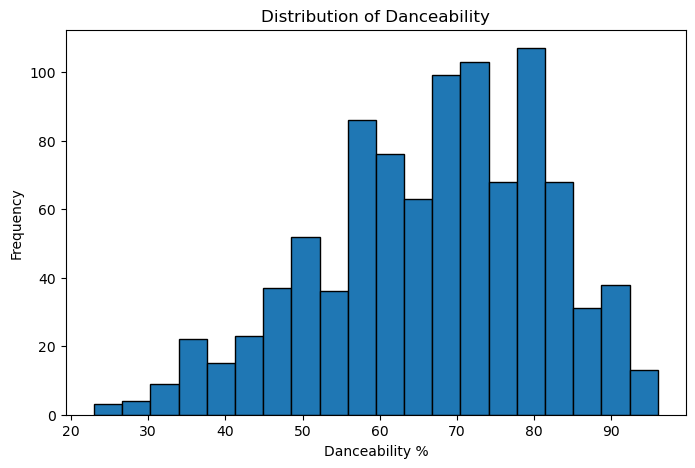

,feature,mean,median,Q1,Q3,min,max
0,danceability_%,66.97,69.0,57.0,78.0,23,96


In [8]:
show_numeric_feature(df, 'danceability_%', 'Distribution of Danceability', 'Danceability %')

Danceability measures how suitable a song is for dancing. The histogram shows where most songs are concentrated, and I will use the middle 50% of values as the target danceability range for the engineered smash hit.

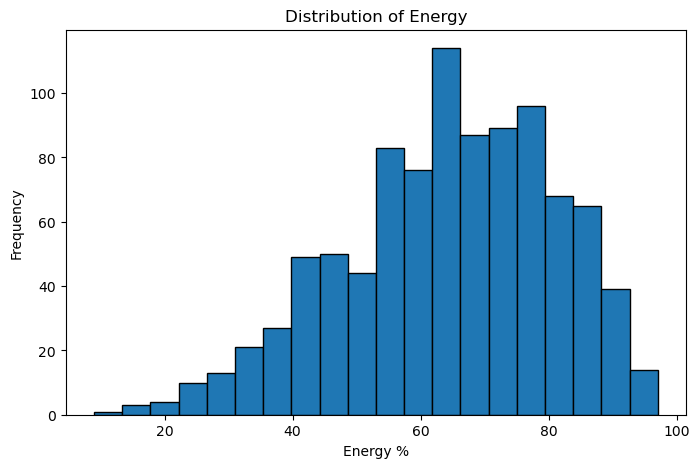

,feature,mean,median,Q1,Q3,min,max
0,energy_%,64.28,66.0,53.0,77.0,9,97


In [9]:
show_numeric_feature(df, 'energy_%', 'Distribution of Energy', 'Energy %')

Energy represents the intensity and activity level of a song. 
The histogram suggests that most popular songs are moderately to highly energetic. 
I will use the middle 50% of energy values as the target range for the engineered smash hit.

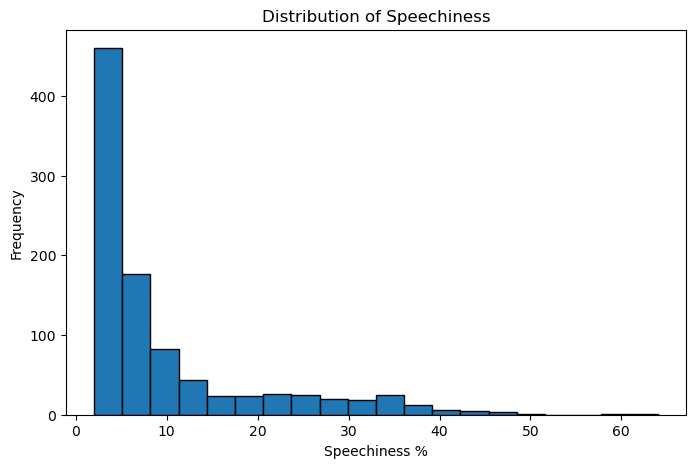

,feature,mean,median,Q1,Q3,min,max
0,speechiness_%,10.13,6.0,4.0,11.0,2,64


In [10]:
show_numeric_feature(df, 'speechiness_%', 'Distribution of Speechiness', 'Speechiness %')

Speechiness measures the amount of spoken-word content in a song. 
Most tracks appear to fall into a lower-to-moderate speechiness range, so I will use the middle 50% of values as the target range for the engineered smash hit.

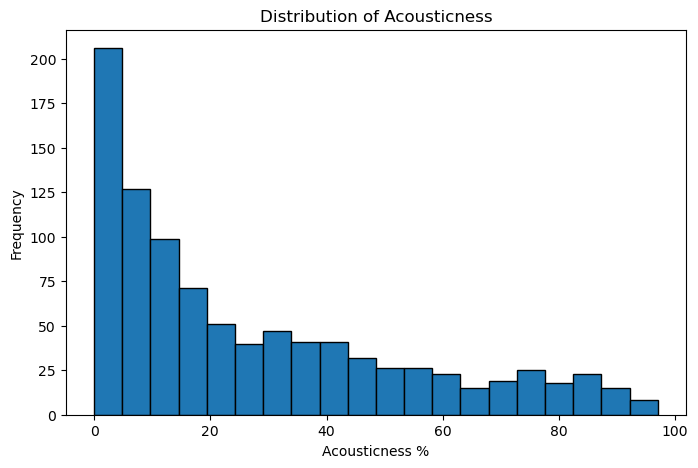

,feature,mean,median,Q1,Q3,min,max
0,acousticness_%,27.06,18.0,6.0,43.0,0,97


In [11]:
show_numeric_feature(df, 'acousticness_%', 'Distribution of Acousticness', 'Acousticness %')

Acousticness indicates how acoustic a song sounds. 
The histogram shows that songs vary widely, but most fall within a middle range rather than at the extreme ends. 
I will use the middle 50% of acousticness values as the target range for the engineered smash hit.

In [12]:
bpm_low = floor(df['bpm'].quantile(0.25))
bpm_high = ceil(df['bpm'].quantile(0.75))

dance_low = floor(df['danceability_%'].quantile(0.25))
dance_high = ceil(df['danceability_%'].quantile(0.75))

energy_low = floor(df['energy_%'].quantile(0.25))
energy_high = ceil(df['energy_%'].quantile(0.75))

speech_low = floor(df['speechiness_%'].quantile(0.25))
speech_high = ceil(df['speechiness_%'].quantile(0.75))

acoustic_low = floor(df['acousticness_%'].quantile(0.25))
acoustic_high = ceil(df['acousticness_%'].quantile(0.75))

top_key = df['key'].mode(dropna=True)[0]
top_mode = df['mode'].mode(dropna=True)[0]

criteria_table = pd.DataFrame({
    'Feature': ['BPM', 'Key', 'Mode', 'Danceability', 'Energy', 'Speechiness', 'Acousticness'],
    'Engineered Hit Value/Range': [
        f'{bpm_low} to {bpm_high}',
        top_key,
        top_mode,
        f'{dance_low} to {dance_high}',
        f'{energy_low} to {energy_high}',
        f'{speech_low} to {speech_high}',
        f'{acoustic_low} to {acoustic_high}'
    ]
})

display(criteria_table)

,Feature,Engineered Hit Value/Range
0,BPM,100 to 140
1,Key,C#
2,Mode,Major
3,Danceability,57 to 78
4,Energy,53 to 77
5,Speechiness,4 to 11
6,Acousticness,6 to 43


Based on the visualizations and calculations, the engineered smash hit should use the most common categorical values and stay within the middle 50% range for the quantitative features. 
This gives the song the most typical combination of musical characteristics found in the dataset.

In [13]:
engineered_hits = df[
    (df['bpm'].between(bpm_low, bpm_high)) &
    (df['key'] == top_key) &
    (df['mode'] == top_mode) &
    (df['danceability_%'].between(dance_low, dance_high)) &
    (df['energy_%'].between(energy_low, energy_high)) &
    (df['speechiness_%'].between(speech_low, speech_high)) &
    (df['acousticness_%'].between(acoustic_low, acoustic_high))
].copy()

engineered_hits['popular_on_spotify_chart'] = engineered_hits['in_spotify_charts'] > 0

clean_engineered_hits = engineered_hits[
    [
        'track_name', 'artist(s)_name', 'streams', 'in_spotify_charts',
        'popular_on_spotify_chart', 'bpm', 'key', 'mode',
        'danceability_%', 'energy_%', 'speechiness_%', 'acousticness_%'
    ]
].sort_values(by='streams', ascending=False).reset_index(drop=True)

print(f"Songs matching all criteria: {len(clean_engineered_hits)}")
display(clean_engineered_hits)

Songs matching all criteria: 2


,track_name,artist(s)_name,streams,in_spotify_charts,popular_on_spotify_chart,bpm,key,mode,danceability_%,energy_%,speechiness_%,acousticness_%
0,Ginseng Strip 2002,Yung Lean,240769997,0,False,115,C#,Major,60,71,4,8
1,Need To Know,Doja Cat,1042568408,0,False,130,C#,Major,66,61,7,30


This table shows whether any songs in the dataset match every part of the engineered smash hit profile. 
If there are matches, I can use their stream counts and Spotify chart presence to judge whether they were actually popular. 
If there are no exact matches, that suggests real hit songs may share common traits without following a perfect formula.

Based on my visualizations and calculations, a guaranteed smash hit would most likely have the following features: **BPM between 100 and 140**, **key of C#**, **mode of Major**, **danceability between 57 and 78**, **energy between 53 and 77**, **speechiness between 4 and 11**, and **acousticness between 6 and 43**.

Using these criteria, I found **2 songs** in the Spotify dataset that match all of the engineered hit characteristics: **"Ginseng Strip 2002" by Yung Lean** and **"Need To Know" by Doja Cat**. Based on their stream counts, these songs were popular, even though they were not listed as currently appearing in the Spotify charts in this dataset.


In [14]:
smash_hit = df[df['track_name'].str.contains('Cruel Summer', case=False, na=False)].copy()

display(
    smash_hit[
        [
            'track_name', 'artist(s)_name', 'streams', 'bpm', 'key', 'mode',
            'danceability_%', 'energy_%', 'speechiness_%', 'acousticness_%'
        ]
    ].reset_index(drop=True)
)

,track_name,artist(s)_name,streams,bpm,key,mode,danceability_%,energy_%,speechiness_%,acousticness_%
0,Cruel Summer,Taylor Swift,800840817,170,A,Major,55,72,15,11


In [15]:
if not smash_hit.empty:
    song = smash_hit.iloc[0]

    comparison_table = pd.DataFrame({
        'Feature': ['BPM', 'Key', 'Mode', 'Danceability', 'Energy', 'Speechiness', 'Acousticness'],
        'Cruel Summer Value': [
            song['bpm'],
            song['key'],
            song['mode'],
            song['danceability_%'],
            song['energy_%'],
            song['speechiness_%'],
            song['acousticness_%']
        ],
        'Engineered Hit Target': [
            f'{bpm_low} to {bpm_high}',
            top_key,
            top_mode,
            f'{dance_low} to {dance_high}',
            f'{energy_low} to {energy_high}',
            f'{speech_low} to {speech_high}',
            f'{acoustic_low} to {acoustic_high}'
        ],
        'Matches Target': [
            bpm_low <= song['bpm'] <= bpm_high,
            song['key'] == top_key,
            song['mode'] == top_mode,
            dance_low <= song['danceability_%'] <= dance_high,
            energy_low <= song['energy_%'] <= energy_high,
            speech_low <= song['speechiness_%'] <= speech_high,
            acoustic_low <= song['acousticness_%'] <= acoustic_high
        ]
    })

    display(comparison_table)

,Feature,Cruel Summer Value,Engineered Hit Target,Matches Target
0,BPM,170,100 to 140,False
1,Key,A,C#,False
2,Mode,Major,Major,True
3,Danceability,55,57 to 78,False
4,Energy,72,53 to 77,True
5,Speechiness,15,4 to 11,False
6,Acousticness,11,6 to 43,True


I chose **"Cruel Summer" by Taylor Swift** as a real smash hit to compare against the engineered hit profile. The song has a **BPM of 170**, is in the **key of A**, uses **Major mode**, has a **danceability of 55**, **energy of 72**, **speechiness of 15**, and **acousticness of 11**.

When compared to the engineered hit criteria, **"Cruel Summer" matched 3 out of 7 features**. This shows that real smash hits often share several common musical traits with other popular songs, but they do not always match every typical feature exactly. That suggests popularity is influenced by more than just the most common audio characteristics.


In this lab, I visualized BPM, key, mode, danceability, energy, speechiness, and acousticness to identify the most typical characteristics of recent popular Spotify songs. 
I used the most common key and mode and the middle 50% range for the quantitative features to design an engineered smash hit profile.

After filtering the dataset, I determined whether any songs matched all of the engineered hit criteria. 
This helped test the idea that a hit song can be created by combining the most common features of recent songs.

I also compared a known smash hit to the engineered profile. 
This comparison showed that real hit songs often match several common traits, but they do not always follow a perfect formula. 
Overall, the dataset suggests that common musical patterns matter, but they are not the only reason a song becomes a smash hit.